### Revisiting solar inflow calculation methodology
CONTEXT - The solar inflow I have been calculating in my pipeline is giving specific numbers for solar inflow at different times (not a continual data changing with time). In the notebook, I am examining and revising the logic used in "window_solar_inflow" function defines in ifc_calculators.py 

For this exploration, I am focusing on just one window in JS's room (extracted directly from the ORIGINAL IFC file instead of the whole site object and window object creation pipeline that is needed for the project - since my focus rn is only the calculation of solar inflow). Plan is to operate directly on an IFC window element, extracting its physical and thermal properties using ifcopenshell, while hardcoding the BK Delft site coordinates.

* Note - this code currently assumes windows to have azimuth value 180° (south-facing) 

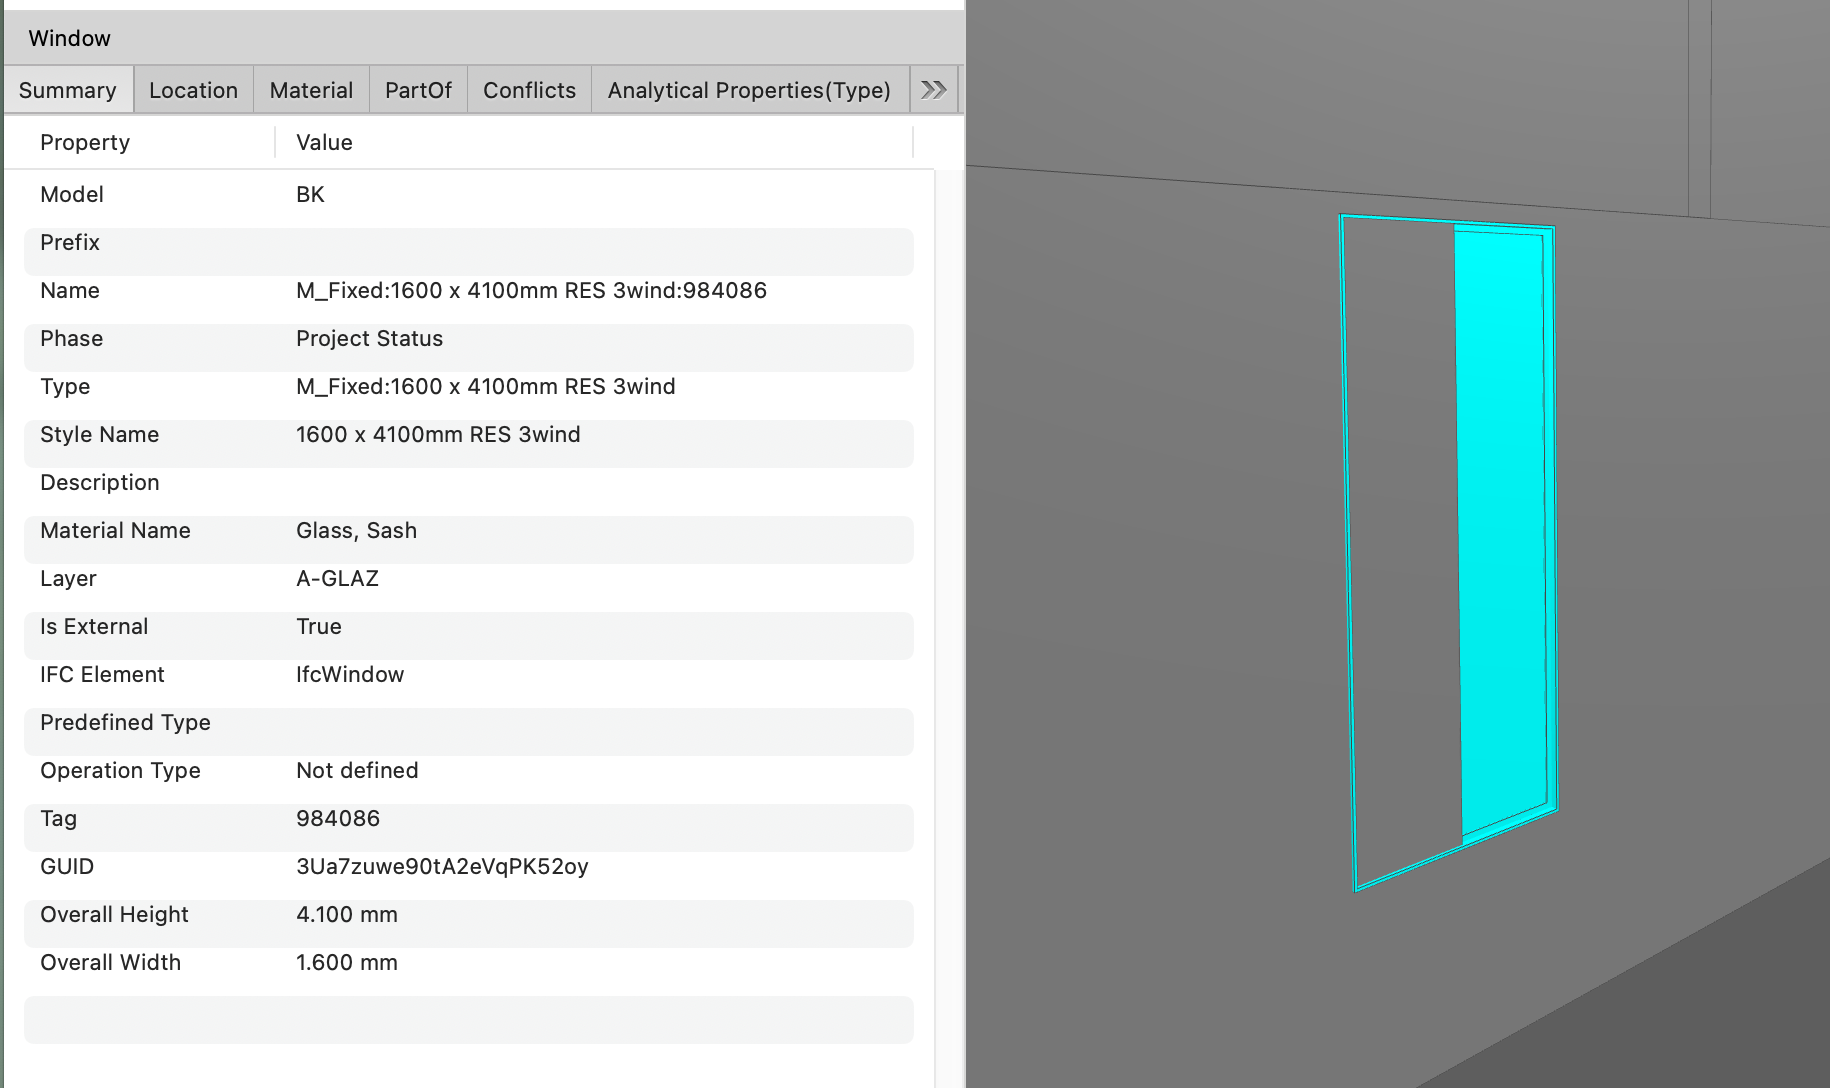

In [1]:
%pip install pvlib

Note: you may need to restart the kernel to use updated packages.


#### hourly simulation + chart for 4th April 2025

/var/folders/x0/pfw_gww561scltw4nh22kh640000gn/T/ipykernel_30907/2815521564.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range = pd.date_range(


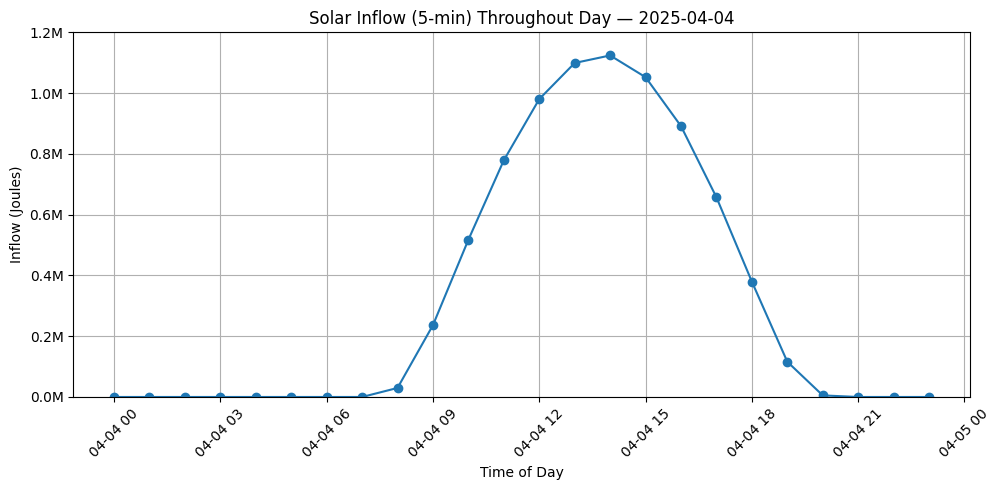

In [11]:
import ifcopenshell
import pandas as pd
import pvlib
import matplotlib.pyplot as plt
from typing import Tuple
import matplotlib.ticker as ticker

def daily_solar_inflow_from_ifc_window(
    ifc_window,
    date: str = "2025-04-04",
    azimuth: float = 180.0,  # Optional override
    tilt: float = 90.0       # Optional override (90° = vertical window)
) -> pd.DataFrame:
    """
    Calculate hourly solar inflow over a full day for a given IFC window.
    Returns DataFrame of timestamps, irradiance, inflow
    """

    # Bouwkunde TU Delft site coordinates
    latitude = 52 + 0/60 + 20/3600 + 0.55684869794 / 1_000_000
    longitude = 4 + 22/60 + 15/3600 + 0.8261705353175 / 1_000_000
    elevation = 0.0
    timezone = "Europe/Amsterdam"

    time_range = pd.date_range(
        start=f"{date} 00:00:00",
        end=f"{date} 23:59:59",
        freq="1H",
        tz=timezone
    )

    # Solar position and atmosphere
    solpos = pvlib.solarposition.get_solarposition(time_range, latitude, longitude)
    airmass = pvlib.atmosphere.get_absolute_airmass(
        pvlib.atmosphere.get_relative_airmass(solpos["apparent_zenith"]))
    linke_turbidity = pvlib.clearsky.lookup_linke_turbidity(time_range, latitude, longitude)

    clearsky = pvlib.clearsky.ineichen(
        apparent_zenith=solpos["apparent_zenith"],
        airmass_absolute=airmass,
        linke_turbidity=linke_turbidity,
        altitude=elevation
    )

    # Geometry
    height = float(ifc_window.OverallHeight or 0.0) / 1000
    width = float(ifc_window.OverallWidth or 0.0) / 1000
    area = height * width

    # SHGC
    shgc = None
    for def_prop in ifc_window.IsDefinedBy:
        prop_set = def_prop.RelatingPropertyDefinition
        if prop_set.is_a("IfcPropertySet") and hasattr(prop_set, "HasProperties"):
            for prop in prop_set.HasProperties:
                if prop.Name in ["Solar Heat Gain Coefficient", "SHGC"] and hasattr(prop, "NominalValue"):
                    shgc = float(prop.NominalValue.wrappedValue)
                    break
    if shgc is None:
        shgc = 0.7  # default if unavailable

    # Plane-of-array irradiance
    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        dni=clearsky["dni"],
        ghi=clearsky["ghi"],
        dhi=clearsky["dhi"],
        solar_zenith=solpos["apparent_zenith"],
        solar_azimuth=solpos["azimuth"]
    )

    I_poa = poa["poa_global"]
    inflow = area * shgc * I_poa * 5 * 60  # Energy in J (5-minute window)

    df = pd.DataFrame({
        "timestamp": time_range,
        "poa_global_Wm2": I_poa,
        "solar_inflow_J": inflow
    })
    return df


# Example with dummy window (you should replace this with real IFC data)
class DummyIFCWindow:
    OverallHeight = 4100  # mm
    OverallWidth = 1600   # mm
    IsDefinedBy = []

class DummyProperty:
    def __init__(self, name, value):
        self.Name = name
        self.NominalValue = type("Val", (), {"wrappedValue": value})

class DummyPropertySet:
    def is_a(self, _): return True
    HasProperties = [DummyProperty("Solar Heat Gain Coefficient", 0.78)]

class DummyDef:
    RelatingPropertyDefinition = DummyPropertySet()

dummy_window = DummyIFCWindow()
dummy_window.IsDefinedBy = [DummyDef()]

# Run and plot
df = daily_solar_inflow_from_ifc_window(dummy_window, date="2025-04-04")

plt.figure(figsize=(10, 5))
plt.plot(df["timestamp"], df["solar_inflow_J"], marker='o')
plt.title("Solar Inflow (5-min) Throughout Day — 2025-04-04")
plt.xlabel("Time of Day")
plt.ylabel("Inflow (Joules)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.ylim(0, 1.2e6)
plt.show()

#### hourly simulation + chart for 5th May 2025

/var/folders/x0/pfw_gww561scltw4nh22kh640000gn/T/ipykernel_30907/1581894482.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range = pd.date_range(


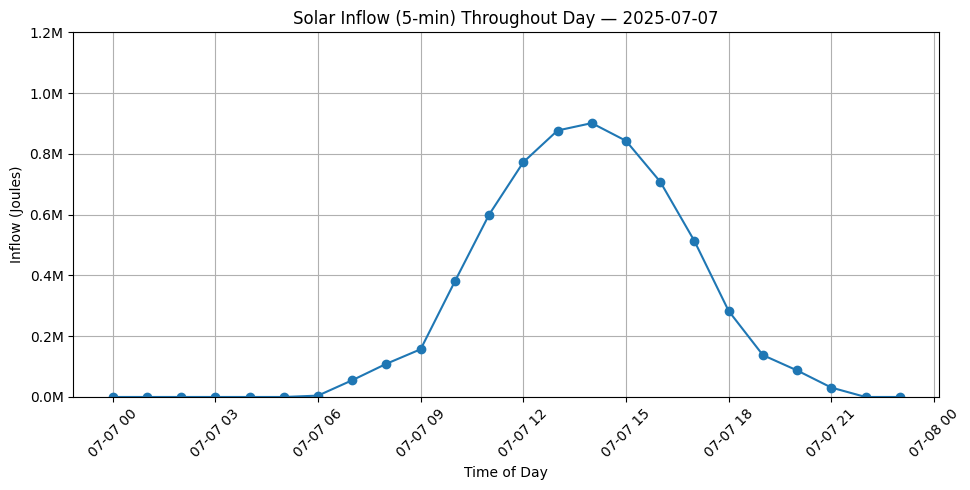

In [10]:
import ifcopenshell
import pandas as pd
import pvlib
import matplotlib.pyplot as plt
from typing import Tuple
import matplotlib.ticker as ticker


def daily_solar_inflow_from_ifc_window(
    ifc_window,
    date: str = "2025-07-07",
    azimuth: float = 180.0,  # Optional override
    tilt: float = 90.0       # Optional override (90° = vertical window)
) -> pd.DataFrame:
    """
    Calculate hourly solar inflow over a full day for a given IFC window.
    Returns DataFrame of timestamps, irradiance, inflow
    """

    # Bouwkunde TU Delft site coordinates
    latitude = 52 + 0/60 + 20/3600 + 0.55684869794 / 1_000_000
    longitude = 4 + 22/60 + 15/3600 + 0.8261705353175 / 1_000_000
    elevation = 0.0
    timezone = "Europe/Amsterdam"

    time_range = pd.date_range(
        start=f"{date} 00:00:00",
        end=f"{date} 23:59:59",
        freq="1H",
        tz=timezone
    )

    # Solar position and atmosphere
    solpos = pvlib.solarposition.get_solarposition(time_range, latitude, longitude)
    airmass = pvlib.atmosphere.get_absolute_airmass(
        pvlib.atmosphere.get_relative_airmass(solpos["apparent_zenith"]))
    linke_turbidity = pvlib.clearsky.lookup_linke_turbidity(time_range, latitude, longitude)

    clearsky = pvlib.clearsky.ineichen(
        apparent_zenith=solpos["apparent_zenith"],
        airmass_absolute=airmass,
        linke_turbidity=linke_turbidity,
        altitude=elevation
    )

    # Geometry
    height = float(ifc_window.OverallHeight or 0.0) / 1000
    width = float(ifc_window.OverallWidth or 0.0) / 1000
    area = height * width

    # SHGC
    shgc = None
    for def_prop in ifc_window.IsDefinedBy:
        prop_set = def_prop.RelatingPropertyDefinition
        if prop_set.is_a("IfcPropertySet") and hasattr(prop_set, "HasProperties"):
            for prop in prop_set.HasProperties:
                if prop.Name in ["Solar Heat Gain Coefficient", "SHGC"] and hasattr(prop, "NominalValue"):
                    shgc = float(prop.NominalValue.wrappedValue)
                    break
    if shgc is None:
        shgc = 0.7  # default if unavailable

    # Plane-of-array irradiance
    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        dni=clearsky["dni"],
        ghi=clearsky["ghi"],
        dhi=clearsky["dhi"],
        solar_zenith=solpos["apparent_zenith"],
        solar_azimuth=solpos["azimuth"]
    )

    I_poa = poa["poa_global"]
    inflow = area * shgc * I_poa * 5 * 60  # Energy in J (5-minute window)

    df = pd.DataFrame({
        "timestamp": time_range,
        "poa_global_Wm2": I_poa,
        "solar_inflow_J": inflow
    })
    return df


# Example with dummy window (you should replace this with real IFC data)
class DummyIFCWindow:
    OverallHeight = 4100  # mm
    OverallWidth = 1600   # mm
    IsDefinedBy = []

class DummyProperty:
    def __init__(self, name, value):
        self.Name = name
        self.NominalValue = type("Val", (), {"wrappedValue": value})

class DummyPropertySet:
    def is_a(self, _): return True
    HasProperties = [DummyProperty("Solar Heat Gain Coefficient", 0.78)]

class DummyDef:
    RelatingPropertyDefinition = DummyPropertySet()

dummy_window = DummyIFCWindow()
dummy_window.IsDefinedBy = [DummyDef()]

# Run and plot
df = daily_solar_inflow_from_ifc_window(dummy_window, date="2025-07-07")

plt.figure(figsize=(10, 5))
plt.plot(df["timestamp"], df["solar_inflow_J"], marker='o')
plt.title("Solar Inflow (5-min) Throughout Day — 2025-07-07")
plt.xlabel("Time of Day")
plt.ylabel("Inflow (Joules)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.ylim(0, 1.2e6)
plt.show()

### 4th April v/s 5th May v/s 7th July



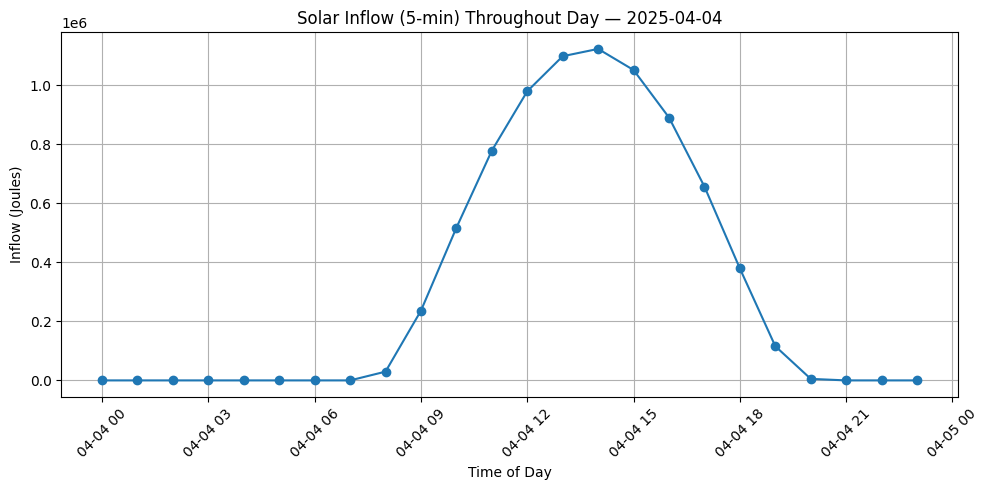

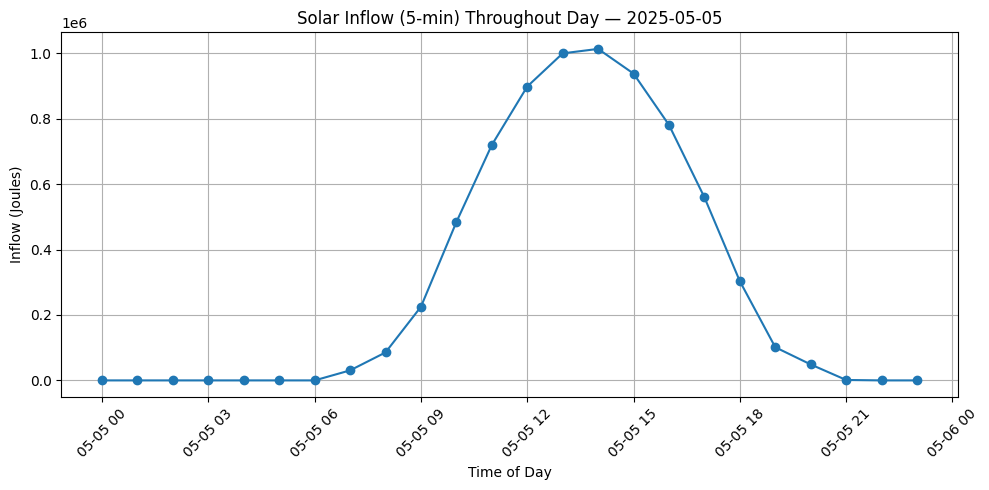

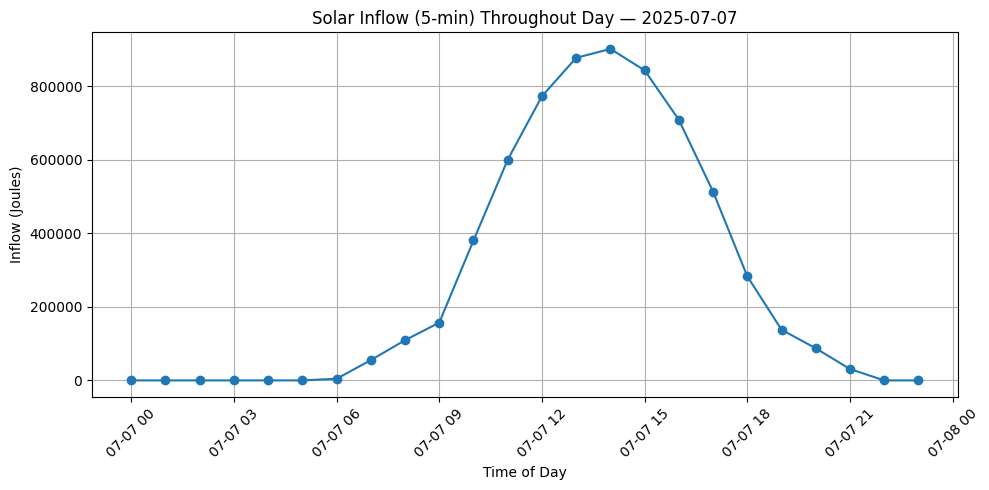